# Pedestrian Collision Severity in London: Does Greenspace Accessibility Improve Prediction of Severe Pedestrian Injury Outcomes?

## Preparation

- [Github link](google.com) *[Optional]*

- Number of words: ***

- Runtime: *** hours (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker (or anything else)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **watermark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.
    - ......

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## 1. Introduction

[[ go back to the top ]](#Table-of-contents)

Pedestrian road safety is a urban policy and health challenge. Road collision events are found to be an interplay between human behaviour, vehicle characteristics, environmental conditions and the characteristics of the infrastructure (Hossain et al., 2026). Under complex urban contexts like London, pedestrians are the most vulnerable, facing disproportionately more severe injury outcomes in comparison to other road users (Pour-Rouholamin and Zhou, 2016). The World Health Organization (2023) reported that more than half of global road traffic fatalities involve vulnerable road users, highlighting the urge of understanding and addressing the challenge. Walking is also a fundamental mode of transport within the built environment, delivering benefits for urban health, community, and environmental sustainability (Mayor of London and Transport for London, n.d.). Pedestrian collisions, as a leading cause of deaths and serious injuries, therefore, make the factors shaping pedestrian injury severity an important policy concern.

This is relevant in London, where road safety and urban greening are both central policy objectives. The Mayor of London aims for promoting "Green Transport" and a "Vision Zero" in eliminating all deaths and serious injuries from road collisions by 2041, targeting safer streets, safer speeds and the transformation of dangerous junctions (Mayor of London and Transport for London, n.d.; Transport for London, n.d.). On the other hand, the London Plan 2021 policies G1, G3 and G4 recognised green infrastructure as a facilitator for walking opportunities and urban health, while the Green Transport strategy further positions urban greening as an incentive to making walking more attractive (Mayor of London, 2021). Despite strong policy commitments links, whether proximity to greenspace shapes pedestrian collision outcomes beyond widely recognised traffic and casualty factors remains underexplored.

While existing literature identifies pedestrian demographics, vehicle type and manoeuvre, road conditions, environmental aspects, and junction characteristics as the primary determinants of collision severity, less attention has been paid to whether greenspace accessibility adds explanatory value (Clifton, Burnier and Akar, 2009; Elalouf, Birfir and Rosenbloom, 2023). While policy links greenspace to increased pedestrian activity and walking attractiveness, whether the collision environments near greenspace access points associated with more severe pedestrian injury outcomes beyond the road and vehicle characteristics remains underexplored.

Pedestrian safety is a major urban policy and public health concern because severe pedestrian injuries reflect not only traffic conditions, but also the interaction between urban design, pedestrian behaviour, environmental context, and neighbourhood characteristics. Therefore, this analysis aims to address the gap by examining London pedestrian road safety data for 2024, testing whether proximity to urban greenspace contributes to fatal or serious injury outcomes after accounting for casualty, collision and vehicle factors. A better understanding of factors is fundamental to implement appropriate policy strategies toward a safer and greener London (Pour-Rouholamin and Zhou, 2016).

## 2. Research questions

[[ go back to the top ]](#Table-of-contents)

This study focuses on pedestrian casualties in London and examines whether greenspace accessibility adds meaningful predictive value beyond established casualty, road, vehicle and temporal predictors. The analysis addresses two research questions:

**RQ1**: Which casualty, road, vehicle and temporal factors are most important for predicting fatal or serious pedestrian injury outcomes in London in 2024?

**RQ2**: Does proximity to urban greenspace access points improve the prediction of fatal or serious pedestrian injury outcomes after accounting for casualty, road, vehicle, temporal and spatial context?

## 3. Data

[[ go back to the top ]](#Table-of-contents)

This analysis uses 2024 data only. Although adding additional years would increase the sample size, a single-year design was chosen to maintain a consistent temporal frame, avoid additional harmonisation issues, and keep the modelling workflow reproducible. The 2024 dataset is sufficient for comparing feature groups and examining whether greenspace proximity adds incremental predictive value.

### 3.1. Load Packages

In [1]:
# Packages to install first prior to loading packages
# %pip install shap

In [2]:
# Data wrangling
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

# Spatial analysis
from libpysal import weights
from esda.moran import Moran, Moran_Local
import matplotlib.patches as mpatches

# Pre-processing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Train test split and cross-validation
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV

# Modelling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV

# Model Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    PrecisionRecallDisplay, RocCurveDisplay
)

# Interpretation
import shap
from sklearn.inspection import PartialDependenceDisplay

# Plot
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

### 3.2. Data Loading

In [3]:
# Load Collision 2024
collision = pd.read_csv("https://raw.githubusercontent.com/christychoicc/DSSS_Coursework/main/dft-road-casualty-statistics-collision-2024.csv", low_memory=False)

# Load Casualty 2024 
casualty = pd.read_csv("https://raw.githubusercontent.com/christychoicc/DSSS_Coursework/main/dft-road-casualty-statistics-casualty-2024.csv", low_memory=False)

# Load Vehicle 2024 
vehicle = pd.read_csv("https://raw.githubusercontent.com/christychoicc/DSSS_Coursework/main/dft-road-casualty-statistics-vehicle-2024.csv", low_memory=False)

# Load Green Space data
greenspace = gpd.read_file("https://raw.githubusercontent.com/christychoicc/DSSS_Coursework/main/OS-Open-Greenspace-GB/GB_AccessPoint.shp")

# Load London LOSA boundary data
london_lsoa = gpd.read_file("https://raw.githubusercontent.com/christychoicc/DSSS_Coursework/main/london_LSOA_boundary/LSOA_2011_London_gen_MHW.shp")

# Load Lower layer Super Output Area population estimates data
london_lsoa_pop = pd.read_csv("https://raw.githubusercontent.com/christychoicc/DSSS_Coursework/main/lsoa_pop_london_2024.csv", low_memory=False)
# The above file was pre-loaded and pre-filtered for analysis needs as original file size exceed github 50MB limits 
# Pre-loaded and pre-filtered code:
# lsoa_pop = pd.read_excel(
#     'sapelsoasyoa20222024.xlsx',
#     sheet_name='Mid-2024 LSOA 2021',
#     skiprows=4
# )
# # Extract needed data and saved as CSV
# pop = lsoa_pop.iloc[:, [2, 4]].copy()
# pop.columns = ['LSOA11CD', 'population']
# pop_london = pop[pop['LSOA11CD'].str.startswith('E01')].copy()
# pop_london.to_csv('lsoa_pop_london_2024.csv', index=False)

# Standardise column names
collision.columns = collision.columns.str.strip().str.lower()
casualty.columns = casualty.columns.str.strip().str.lower()
vehicle.columns = vehicle.columns.str.strip().str.lower()
greenspace.columns = greenspace.columns.str.strip().str.lower()

In [4]:
# # Data Inspection

# # Inspect number of rows and columns for all dataset
# print("Collision data shape:", collision.shape)
# print("Casualty data shape:", casualty.shape)
# print("Vehicle data shape:", vehicle.shape)
# print("Greenspace data shape:", greenspace.shape)
# print("London LSOA shape:", london_lsoa.shape)

# # Inspect CRS for greenspace and London boundary data
# print("\nGreenspace CRS:", greenspace.crs)
# print("London LSOA CRS:", london_lsoa.crs)

# # Inspect column names for all dataset
# print("\nCollision Column names:")
# print(collision.columns.tolist())
# print("\nCasualty Column names:")
# print(casualty.columns.tolist())
# print("\nVehicle Column names:")
# print(vehicle.columns.tolist())
# print("\nGreenspace Column names:")
# print(greenspace.columns.tolist())

### 3.3. Data Pre-processing

#### 3.3.1. Data Cleaning 

In [5]:
# Filter to London collisions only
collision_london = collision[
    collision['local_authority_ons_district'].astype(str).str.startswith('E09')
].copy()

# print("London collisions shape:", collision_london.shape)
# print(collision_london['local_authority_ons_district'].nunique())

In [6]:
# Filter Greenspace data to London only
# Using london_lsoa dataset to set london boundary
london_boundary = london_lsoa.dissolve()
# Ensure consistent CRS
greenspace = greenspace.to_crs(london_boundary.crs)
# Clip greenspace to the exact London boundary
greenspace_london = gpd.clip(greenspace, london_boundary)


# Transform geometry column's point(x y z) into normal point(x y) only
greenspace_london['geometry'] = greenspace_london['geometry'].apply(
    lambda g: Point(g.x, g.y)  # drops Z, keeps X and Y only
)

# Create collision points for calculating nearest greenspace distance
collision_points = gpd.GeoDataFrame(
    # remove duplicated collision_index
    collision_london[['collision_index', 'longitude', 'latitude']].dropna().drop_duplicates('collision_index'),
    # convert lat and long to geometry
    geometry=gpd.points_from_xy(
        collision_london[['collision_index', 'longitude', 'latitude']].dropna().drop_duplicates('collision_index')['longitude'],
        collision_london[['collision_index', 'longitude', 'latitude']].dropna().drop_duplicates('collision_index')['latitude']
    ),
    crs='EPSG:4326'
).to_crs('EPSG:27700')

# Nearest greenspace access point
collision_green_nearest = gpd.sjoin_nearest(
    collision_points,
    greenspace_london[['geometry']],
    how='left',
    distance_col='dist_to_greenspace_m'
)[['collision_index', 'dist_to_greenspace_m']].drop_duplicates('collision_index')

# Merge newly computed collisioin to nearest greenspace a.p. with london collision
collision_london = collision_london.merge(
    collision_green_nearest,
    on='collision_index',
    how='left'
)

Distance to the nearest greenspace access point was calculated using OS Open Greenspace access-point geometries. The collision coordinates were converted to British National Grid (EPSG:27700), allowing distance to be measured in metres. This variable is interpreted as a measure of spatial proximity to public greenspace access, rather than as a direct measure of pedestrian exposure or park usage.

In [7]:
# Filter to Pedestrian casualties only
# 3 = Pedestrians
casualty_ped = casualty[casualty['casualty_class'] == 3].copy()

In [8]:
# Filter for London Pedestrian casualties only
casualty_ped_london = casualty_ped[
    casualty_ped['collision_index'].isin(collision_london['collision_index'])
].copy()

In [9]:
# Check how many collision have more than one pedestrian casualty
peds_per_collision = casualty_ped_london.groupby('collision_index').size()

print("Number of pedestrian-collision rows:", len(casualty_ped_london))
print("Number of unique collisions involving pedestrians:", casualty_ped_london['collision_index'].nunique())
print("Number of collisions with >1 pedestrian casualty:", (peds_per_collision > 1).sum())
print("Maximum pedestrians in a single collision:", peds_per_collision.max())

Number of pedestrian-collision rows: 4445
Number of unique collisions involving pedestrians: 4299
Number of collisions with >1 pedestrian casualty: 127
Maximum pedestrians in a single collision: 4


The analysis is conducted at casualty level rather than collision level, therefore each row represents one pedestrian casualty. This is appropriate as the target variable is casualty severity, which is recorded for each injury rather than for the collision as a whole. A small number of collisions involve more than one pedestrian casualty, where some observations are not fully independent. In 2024, 127 pedestrian collisions in London involved more than one pedestrian casualty, with a maximum of four pedestrian casualties in a single collision. This is considered as a minor limitation, as the scale is small relative to the full sample of 4,445 pedestrian casualties.

#### 3.3.2. Data Merge / Joins

In [10]:
# Merge casualty, collision, and vehicle data
df_merge = (
    # Merge pedestrian casualties
    casualty_ped_london
    .merge(
        # with London collisions
        collision_london.drop(columns=['collision_year', 'collision_ref_no'], errors='ignore'),
        on='collision_index',
        how='left'
    )
    .merge(
        # with vehicles
        vehicle.drop(columns=['collision_year', 'collision_ref_no'], errors='ignore'),
        on=['collision_index', 'vehicle_reference'],
        how='left'
    )
)

In [11]:
# # Check variables after merge
# print(df_merge.columns.tolist())

### 3.4. Data Wrangling

#### 3.4.1. Data Ambiguity 

In [12]:
# # Check ambiguity of potentially needed variables
# ambiguous_codes = {
#     # casualty (pedestrian data)
#     'sex_of_casualty':          [-1, 9],
#     'age_of_casualty':          [-1],
#     'pedestrian_location':      [-1, 10],
#     'pedestrian_movement':      [-1, 9],
#     'pedestrian_road_maintenance_worker': [-1, 2], # also a type of pedestrian so include it
#     'casualty_imd_decile':      [-1],

#     # collision / road environment
#     'speed_limit':              [-1, 99],
#     'first_road_class':         [-1],
#     'road_type':                [-1, 9],
#     'junction_detail':          [-1, 99],
#     'junction_control':         [-1, 9],
#     'pedestrian_crossing':      [-1, 99],
#     'light_conditions':         [-1],
#     'weather_conditions':       [-1, 9],
#     'road_surface_conditions':  [-1, 9],
#     'urban_or_rural_area':      [-1],
#     'trunk_road_flag':          [-1],

#     # vehicle / driver
#     'vehicle_type':             [-1, 99],
#     'vehicle_manoeuvre':        [-1, 99],
#     'junction_location':        [-1, 9],
#     'sex_of_driver':            [-1, 3],
#     'age_of_driver':            [-1],
#     'driver_imd_decile':        [-1],
#     'engine_capacity_cc':       [-1],
#     'age_of_vehicle':           [-1]
# }

# # Print a summary table of unknown missing values
# inspection_rows = []
# for col, codes in ambiguous_codes.items():
#     if col not in df_merge.columns:
#         continue
    
#     total= len(df_merge)
#     actual_nan= df_merge[col].isnull().sum()
#     ambig_count= df_merge[col].isin(codes).sum()
#     total_missing= actual_nan + ambig_count
#     pct= total_missing / total * 100
#     inspection_rows.append({
#         'variable': col,
#         'total_rows': total,
#         'actual_NaN': actual_nan,
#         'ambiguous_codes': str(codes),
#         'ambiguous_count': ambig_count,
#         'total_missing': total_missing,
#         'pct_missing': round(pct, 1)
#     })

# inspection_df = pd.DataFrame(inspection_rows).sort_values('pct_missing', ascending=False)
# print("Missing / Unknown Data Inspection:")
# print(inspection_df.to_string(index=False))

|Variable|Code|Code Interpretation|Action|
|---|---|---|---|
|pedestrian_movement|-1, 9|Missing / unknown or other|Recode to `NaN`, impute with categorical `Missing`|
|junction_control|-1, 9|Missing / unknown|Recode to `NaN`, impute with categorical `Missing`|
|vehicle_manoeuvre|-1, 99|Missing / unknown |Recode to `NaN`, impute with categorical `Missing`|
|junction_location|-1, 9|Missing / unknown|Recode to `NaN`, impute with categorical `Missing`|
|casualty_imd_decile|-1|Missing|Recode to `NaN`, impute with categorical `Missing`|
|pedestrian_location|-1, 10|Missing / unknown or other|Recode to `NaN`, impute with categorical `Missing`|
|junction_detail|-1, 99|Missing / unknown |Recode to `NaN`, impute with categorical `Missing`|
|road_type|-1, 9|Missing / unknown|Recode to `NaN`, impute with categorical `Missing`|
|pedestrian_crossing|-1, 99|Missing / unknown |Recode to `NaN`, impute with categorical `Missing`|
|weather_conditions|-1, 9|Missing / unknown|Recode to `NaN`, impute with categorical `Missing`, keep `8 = Other`|
|road_surface_conditions|-1, 9|Missing / unknown |Recode to `NaN`, impute with categorical `Missing`|
|age_of_casualty|-1|Missing|Recode to `NaN`, impute with median|
|vehicle_type|-1, 99|Missing / unknown vehicle type|Recode to `NaN`, impute with categorical `Missing`, keep `90 = Other vehicle`|
|pedestrian_road_maintenance_worker|-1, 2|Missing / not known|Recode to `NaN`, impute with categorical `Missing`|
|sex_of_casualty|-1, 9|Missing / unknown|Recode to `NaN`, impute with categorical `Missing`|
|speed_limit|-1, 99|Missing / unknown|No action needed |
|first_road_class|-1, 9|Missing / unknown|No action needed|
|light_conditions|-1|Missing|No action needed |
|urban_or_rural_area|-1|Missing|No action needed |
|trunk_road_flag|-1|Missing|No action needed |
|driver_imd_decile|-1|Missing|Exclude from modelling due to high levels of missing data|
|sex_of_driver|-1, 3|Missing / not known|Exclude from modelling due to high levels of missing data|
|age_of_driver|-1|Missing|Exclude from modelling due to high levels of missing data|
|engine_capacity_cc|-1|Missing|Exclude from modelling due to high levels of missing data|
|age_of_vehicle|-1|Missing|Exclude from modelling due to high levels of missing data|

In [13]:
# Variable that needs recoding
recode_nan = {
    # collision
    'junction_control': [-1, 9],
    'junction_detail': [-1, 99],
    'road_type': [-1, 9],
    'pedestrian_crossing': [-1, 99],
    'weather_conditions': [-1, 9],
    'road_surface_conditions': [-1, 9],

    # casualty
    'pedestrian_movement': [-1, 9],
    'casualty_imd_decile': [-1],
    'pedestrian_location': [-1, 10],
    'age_of_casualty': [-1],
    'pedestrian_road_maintenance_worker': [-1, 2], 
    'sex_of_casualty': [-1, 9],

    # vehicle
    'vehicle_manoeuvre': [-1, 99],
    'junction_location': [-1, 9],
    'vehicle_type': [-1, 99] # keep 90 = Others
}

In [14]:
# Set recode function
def apply_recode(df, recode_dict):
    df = df.copy()
    for col, bad_codes in recode_dict.items():
        if col in df.columns:
            df[col] = df[col].replace(bad_codes, np.nan)
    return df

In [15]:
# Apply recode functions to the merged dataset
df_merge_recode = apply_recode(df_merge, recode_nan)

#### 3.4.2. Variables Wrangling

In [16]:
# Extract temporal features from collision date and time

# Convert time to hour
df_merge_recode['time'] = pd.to_datetime(
    df_merge_recode['time'], format='%H:%M', errors='coerce'
)
df_merge_recode['hour'] = df_merge_recode['time'].dt.hour

# Define time periods
def assign_time_period(hour):
    if pd.isna(hour):
        return np.nan
    elif 7 <= hour <= 9:
        return 'Morning Peak'
    elif 10 <= hour <= 15:
        return 'Daytime'
    elif 16 <= hour <= 18:
        return 'Evening Peak'
    elif 19 <= hour <= 22:
        return 'Evening'
    else:
        return 'Night'   # 23:00 - 06:00

df_merge_recode['time_period'] = df_merge_recode['hour'].apply(assign_time_period)

# Create weekday and weekend
df_merge_recode['date'] = pd.to_datetime(
    df_merge_recode['date'], errors='coerce'
)
df_merge_recode['day_of_week'] = df_merge_recode['date'].dt.day_name()
df_merge_recode['day_type'] = df_merge_recode['date'].dt.dayofweek.apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

# Check distributions
print("Time period distribution:")
print(df_merge_recode['time_period'].value_counts())
print("\nDay type distribution:")
print(df_merge_recode['day_type'].value_counts())
print("\nSeverity rate by time period:")
print(df_merge_recode.groupby('time_period')['casualty_severity']
      .apply(lambda x: (x.isin([1,2])).mean()).round(3).sort_values(ascending=False))

Time period distribution:
time_period
Daytime         1539
Evening Peak    1129
Evening          731
Morning Peak     675
Night            371
Name: count, dtype: int64

Day type distribution:
day_type
Weekday    3501
Weekend     944
Name: count, dtype: int64

Severity rate by time period:
time_period
Night           0.329
Evening         0.304
Daytime         0.272
Evening Peak    0.247
Morning Peak    0.230
Name: casualty_severity, dtype: float64


In [17]:
# # Check merged columns 
# print("\n Merged Dataframe Columns:")
# print(df_merge_recode.columns.tolist())

#### 3.4.3. Data Filtering and Data Types
##### Data Filtering

In [18]:
# Select needed columns
selected_columns = [
    # To be used to create our target binary variable
    'casualty_severity',

    # casualty, pedestrian variables
    'sex_of_casualty',
    'age_of_casualty',
    'pedestrian_location',
    'pedestrian_movement',
    'pedestrian_road_maintenance_worker',
    'casualty_imd_decile',
    'lsoa_of_accident_location', # for mapping purposes

    # collision, road and environment variables
    'speed_limit',
    'first_road_class',
    'road_type',
    'junction_detail',
    'junction_control',
    'pedestrian_crossing',
    'light_conditions',
    'weather_conditions',
    'road_surface_conditions',
    'urban_or_rural_area',
    'trunk_road_flag',

    # vehicle, driver variables
    'vehicle_type',
    'vehicle_manoeuvre',
    'junction_location',
    # 'sex_of_driver', # Excluded for high levels missing data
    # 'age_of_driver', # Excluded for high levels missing data
    # 'age_of_vehicle', # Excluded for high levels missing data
    # 'driver_imd_decile', # Excluded for high levels missing data

    # spatial contextual variable
    'dist_to_greenspace_m',

    # temporal variables
    'time_period',
    'day_of_week',
    'day_type'
]

selected_columns = [c for c in selected_columns if c in df_merge_recode.columns]

df_clean = df_merge_recode[selected_columns].copy()

##### Data Types

In [19]:
# Define features by data type and datasets groups

casualty_numeric = ['age_of_casualty']
casualty_categorical = [
    'sex_of_casualty', 'pedestrian_location', 'pedestrian_movement',
    'pedestrian_road_maintenance_worker', 'casualty_imd_decile']

# No numeric features for raod
road_categorical = [
    'speed_limit', 'first_road_class', 'road_type', 'junction_detail',
    'junction_control', 'pedestrian_crossing', 'light_conditions',
    'weather_conditions', 'road_surface_conditions',
    'urban_or_rural_area', 'trunk_road_flag'
]

# No numeric features for vehicle
vehicle_categorical = ['vehicle_type', 'vehicle_manoeuvre', 'junction_location']

# No numeric features for greenspace
greenspace_numeric = ['dist_to_greenspace_m']

# No numeric features for temporal variables
temporal_categorical = ['time_period', 'day_of_week', 'day_type']

# All features in numeric and categorical
numeric_features = casualty_numeric + greenspace_numeric
categorical_features = casualty_categorical + road_categorical + vehicle_categorical + temporal_categorical

# Note* 
# severity_levels are targets so not included here
# casualty_severity used to create severity levels so not included here
# longitude and latitude not included here
# lsoa_of_accident_location not included here

In [20]:
# Assign categroical features as objects (aka categories make them not comparable numbers)

# Numeric columns
# Keep values as numeric
for col in numeric_features:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Categorical columns
# Convert all non-missing values to strings --> keep missing as NaN
for col in categorical_features:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(lambda x: np.nan if pd.isna(x) else str(x))

# Check numeric features are numeric
print("\nNumeric Features:")
print(df_clean[numeric_features].dtypes)

# Check categorical features are strings
print("\nCategorical Features:")
print(df_clean[categorical_features].dtypes)

# Check NaN is preserved correctly (not converted to string "nan")
print("\nNaNs:")
print(df_clean[categorical_features].isnull().sum()[df_clean[categorical_features].isnull().sum() > 0])


Numeric Features:
age_of_casualty         float64
dist_to_greenspace_m    float64
dtype: object

Categorical Features:
sex_of_casualty                       object
pedestrian_location                   object
pedestrian_movement                   object
pedestrian_road_maintenance_worker    object
casualty_imd_decile                   object
speed_limit                           object
first_road_class                      object
road_type                             object
junction_detail                       object
junction_control                      object
pedestrian_crossing                   object
light_conditions                      object
weather_conditions                    object
road_surface_conditions               object
urban_or_rural_area                   object
trunk_road_flag                       object
vehicle_type                          object
vehicle_manoeuvre                     object
junction_location                     object
time_period              

#### 3.4.4. Target Variable 
The binary target variable `severity_levels` was derived from `casualty_severity`:

- `1` = fatal or serious pedestrian injury
- `0` = slight pedestrian injury

Fatal and serious casualties were grouped as fatal casualties recorded observations falls into a minority group which may risk modelling reliability from class imbalance. Furthermore, both categories also represents severe injury outcomes which is most insightful to road safety policy, which therefore is seen as an appropriate measure in groupping severity levels as binary. This binary framing also allows the analysis to focus on whether models can distinguish severe pedestrian injury outcomes from slight injuries.

In [21]:
# Check initial distribution of casualty severity categories
print("Casualty severity data distribution:")
print(df_clean['casualty_severity'].value_counts())

# Create a binary labels for our target (severity levels)
df_clean['severity_levels'] = np.where(df_clean['casualty_severity'].isin([1, 2]), 1, 0)
print("\nCasualty severity groupped binary labels:")
print(df_clean['severity_levels'].value_counts())

Casualty severity data distribution:
casualty_severity
3    3249
2    1135
1      61
Name: count, dtype: int64

Casualty severity groupped binary labels:
severity_levels
0    3249
1    1196
Name: count, dtype: int64


In [22]:
# Check data types in df_clean
print("\n df_clean data types:")
print(df_clean.dtypes)


 df_clean data types:
casualty_severity                       int64
sex_of_casualty                        object
age_of_casualty                       float64
pedestrian_location                    object
pedestrian_movement                    object
pedestrian_road_maintenance_worker     object
casualty_imd_decile                    object
lsoa_of_accident_location              object
speed_limit                            object
first_road_class                       object
road_type                              object
junction_detail                        object
junction_control                       object
pedestrian_crossing                    object
light_conditions                       object
weather_conditions                     object
road_surface_conditions                object
urban_or_rural_area                    object
trunk_road_flag                        object
vehicle_type                           object
vehicle_manoeuvre                      object
junction_lo

#### 3.4.5. Variable Confounding Inspection
Prior to modelling, a potential confounding relationship between distance to the nearest greenspace access point and road speed limit was examined. Greenspace access points in London are mostly located within residential neighbourhoods with lower speed limits, while higher speed roads tend to pass through corridors with fewer greenspace access points. This urban pattern suggests that any observed association between greenspace proximity and pedestrian injury severity may be partially attributable to the correlated road speed environment rather than greenspace accessibility itself. The Spearman correlation showed a weak statistically significant relationship between the two variables with ρ = 0.124 and p < 0.001, indicating that collisions occurring closer to greenspace tend to have lower speed limits. Therefore, both variables will be included as predictors for tree-based modelling approaches, allowing greenspace accessibility to be modelled after accounting for road speed context.

In [23]:
# Check correlation between greenspace distance and speed limit
greenspace_speedlimit_check = df_clean[['dist_to_greenspace_m', 'speed_limit']].copy()
greenspace_speedlimit_check['speed_limit'] = pd.to_numeric(greenspace_speedlimit_check['speed_limit'], errors='coerce')
greenspace_speedlimit_check = greenspace_speedlimit_check.dropna()

rho, pval = spearmanr(greenspace_speedlimit_check['dist_to_greenspace_m'], greenspace_speedlimit_check['speed_limit'])
print(f"Spearman correlation between greenspace distance and speed limit:")
print(f"ρ = {rho:.4f}, p = {pval:.4f}")

# Also show mean greenspace distance by speed limit
mean_greenspace = (
    df_clean.groupby('speed_limit')['dist_to_greenspace_m']
    .mean()
    .reset_index()
    .sort_values('speed_limit')
)
mean_greenspace['speed_limit'] = pd.to_numeric(mean_greenspace['speed_limit'], errors='coerce')
mean_greenspace = mean_greenspace.dropna().sort_values('speed_limit')
print("\nMean greenspace distance by speed limit:")
print(mean_greenspace.to_string(index=False))

Spearman correlation between greenspace distance and speed limit:
ρ = 0.1235, p = 0.0000

Mean greenspace distance by speed limit:
 speed_limit  dist_to_greenspace_m
          20            150.938074
          30            180.468014
          40            194.532716
          50            199.818479
          60            333.308242
          70            643.755792


In [47]:
print(df_clean.columns.tolist())

['casualty_severity', 'sex_of_casualty', 'age_of_casualty', 'pedestrian_location', 'pedestrian_movement', 'pedestrian_road_maintenance_worker', 'casualty_imd_decile', 'lsoa_of_accident_location', 'speed_limit', 'first_road_class', 'road_type', 'junction_detail', 'junction_control', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'urban_or_rural_area', 'trunk_road_flag', 'vehicle_type', 'vehicle_manoeuvre', 'junction_location', 'dist_to_greenspace_m', 'time_period', 'day_of_week', 'day_type', 'severity_levels']


### 3.5. Metadata 

The variables information below shows the cleaned dataframe prior to modelling. Additional pre-processing for tree-based methods analysis, including imputation, scaling, and one-hot encoding will be applied within the modelling pipeline and will not affect the data structure.

| Variable | Type | Description | Notes |
|---|---|---|---|
| severity_levels | Binary | Determine pedestrian injury severity levels: 1 = fatal or serious injury, 0 = slight injury | Target variable |
| casualty_severity | Categorical | Recorded casualty severity levels: 1 = fatal, 2 = serious, 3 = slight | Used to create `severity_levels`variable, will be excluded from modelling |
| sex_of_casualty | Categorical | Sex of the pedestrian casualty | Input Predictor |
| age_of_casualty | Numeric | Age of the pedestrian casualty in years | Input Predictor |
| pedestrian_location | Categorical | Pedestrian's location relative to the carriageway or crossing at collision | Input Predictor |
| pedestrian_movement | Categorical | Reported movement of the pedestrian at collision | Input Predictor |
| pedestrian_road_maintenance_worker | Categorical | Record as a road maintenance worker | Input Predictor |
| casualty_imd_decile | Categorical | Index of Multiple Deprivation decile associated with the area of casualty| Input Predictor |
| lsoa_of_accident_location | ID | LSOA code of the collision location | Retained for spatial exploratory analysis purposes, will be excluded from modelling |
| speed_limit | Categorical | Speed limit of the collision location | Input Predictor |
| first_road_class | Categorical | Classification of the first road at the collision location | Input Predictor |
| road_type | Categorical | Type of road where the collision occurred | Input Predictor |
| junction_detail | Categorical | Type of junction at the collision location | Input Predictor |
| junction_control | Categorical | Tyoe of traffic control present at the junction | Input Predictor |
| pedestrian_crossing | Categorical | Type of pedestrian crossing facility present | Input Predictor |
| light_conditions | Categorical | Lighting conditions at collision | Input Predictor |
| weather_conditions | Categorical | Weather conditions at collision | Input Predictor |
| road_surface_conditions | Categorical | Condition of the road surface at the time of collision | Input Predictor |
| urban_or_rural_area | Categorical | Classification of the collision location as urban or rural | Input Predictor |
| trunk_road_flag | Categorical | Indicator of if the collision occurred on a trunk road | Input Predictor |
| vehicle_type | Categorical | Type of vehicle associated with the pedestrian casualty | Input Predictor |
| vehicle_manoeuvre | Categorical | Manoeuvre of the associated vehicle at collision | Input Predictor |
| junction_location | Categorical | Position of the associated vehicle relative to the junction | Input Predictor |
| dist_to_greenspace_m | Numeric | Distance to the nearest greenspace access point in metres | Spatial Input Predictor, typically for answering RQ2 |
|time_period|Categorical|Time of day as Morning Peak, Daytime, Evening Peak, Evening and Night|Input Predictor|
|day_of_week|Categorical|Day of week on which the collision occurred|Input Predictor|
|day_type|Categorical|Weekday or weekend|Input Predictor|

## 4. Methodology

[[ go back to the top ]](#Table-of-contents)

The analysis uses a spatial machine learning workflow to examine fatal or serious pedestrian injury outcomes in London. 

First, spatial analysis is used to examine the geography of severe pedestrian casualties across London LSOAs. Fatal or serious pedestrian casualty rates per 10,000 residents are mapped, alongside the share of pedestrian casualties in each LSOA that are fatal or serious. Global Moran's I and Local Moran's I are used to assess whether severe pedestrian injury rates show spatial clustering. A class-weighted logistic regression model is used as an interpretable baseline. Logistic regression provides a simpler benchmark against which the random forest models can be compared. It is also used to test whether adding greenspace proximity improves predictive performance in a transparent model structure. Machine learning (ML) approaches has been widely adopted in road safety data analysis, as traditional discrete methods depend on pre-specified assumptions and tends to struggle with noisy data. ML benefits from higher flexibility, ability to acquire only minimal prior assumptions, thus demonstrate stronger predictive (Dong et al., 2022; Tao et al., 2022). For modelling, a class-weighted random forest models are used to compare different feature groups of predictors: casualty, temporal, road, vehicle and greenspace variables. This feature-block design directly tests whether greenspace proximity adds incremental predictive value beyond established road safety predictors. Because fatal or serious injuries are the minority class, class weighting is used and model performance is evaluated using recall, F1-score, ROC-AUC and PR-AUC. PR-AUC is especially useful because it is more informative than accuracy under class imbalance. While ML approaches can establish complex, non-linear relationships between input variables and injury severity outcomes, yet it also face limitations of their black-box nature (Dong et al., 2022). Therefore, the final model will be interpreted using Shapley Additive exPlanations (SHAP) and partial dependence. SHAP is used to rank predictors by their contribution to fatal or serious injury predictions, while partial dependence is used to examine the marginal relationship between greenspace distance and predicted injury severity. Finally, spatial error analysis is used to map false negatives, which are fatal or serious casualties incorrectly predicted as slight. These errors are important because they show where the model fails to identify severe pedestrian injury outcomes.

*[Note: a flow chart that describes the methodology is strongly encouraged - see the example below. This flow chart can be made using Microsoft powerpoint or visio or other software]*

Source: see [link](https://linkinghub.elsevier.com/retrieve/pii/S2210670722004437).

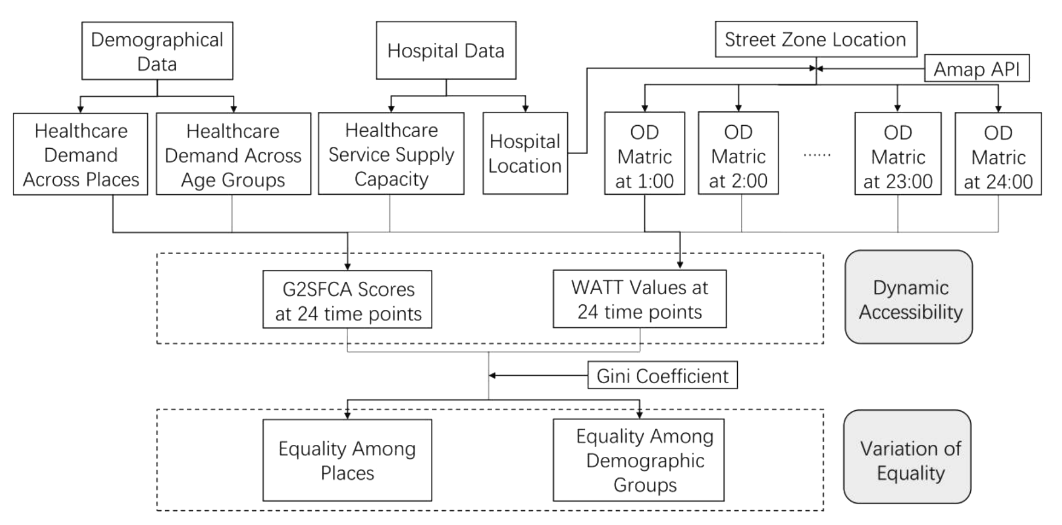

## 5. Results

[[ go back to the top ]](#Table-of-contents)

### 5.1. Exploratory Data Analysis

#### 5.1.1. Pedestrian Severity Levels Data Distribution

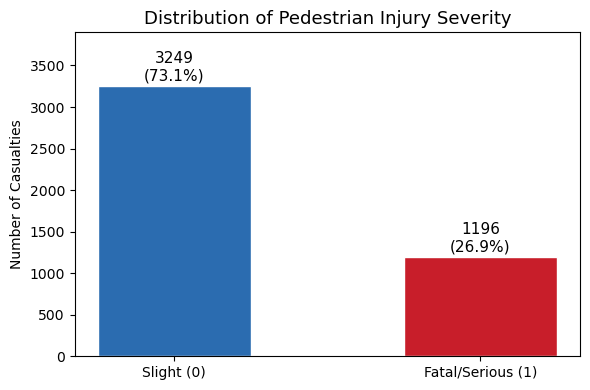

In [24]:
severity_counts = df_clean['severity_levels'].value_counts()
labels = ['Slight (0)', 'Fatal/Serious (1)']
colors = ['#2B6CB0', '#C81E2A']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, severity_counts.values, color=colors, edgecolor='white', width=0.5)

for bar, count in zip(bars, severity_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 30,
            f'{count}\n({count/len(df_clean)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11)

ax.set_title('Distribution of Pedestrian Injury Severity', fontsize=13)
ax.set_ylabel('Number of Casualties')
ax.set_ylim(0, severity_counts.max() * 1.2)
plt.tight_layout()
plt.show()

#### 5.1.2. Heatmap of Age and Speed Limit on Fatal/ Serious Pedestrian Injury

In [25]:
df_clean.speed_limit.describe()

count     4445
unique       6
top         20
freq      2808
Name: speed_limit, dtype: object

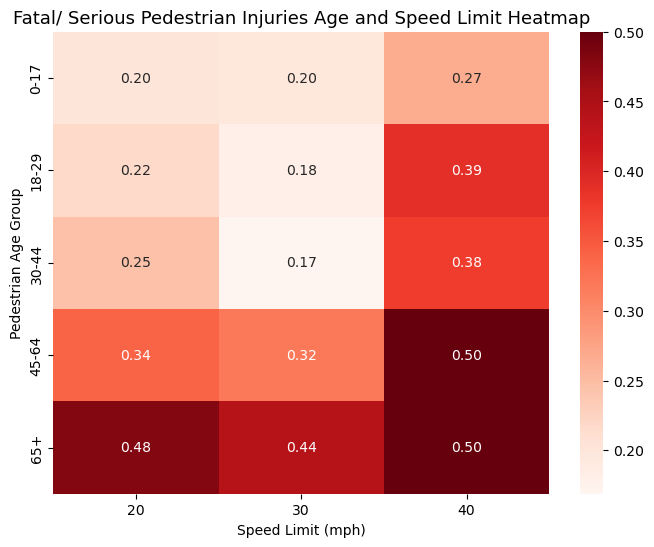

In [26]:
# Ensure speed_limit is numeric
df_clean['speed_limit'] = pd.to_numeric(df_clean['speed_limit'], errors='coerce')

# Select low speed limit 
# As 50, 60 and 70mph roads are for dual carriageways and motorways in the UK (https://www.gov.uk/speed-limits)
target_speeds = [20, 30, 40]
df_filtered = df_clean[df_clean['speed_limit'].isin(target_speeds)].copy()

# Create Age Groups
age_bins = [0, 18, 30, 45, 65, 100]
age_labels = ['0-17', '18-29', '30-44', '45-64', '65+']
df_filtered['age_group'] = pd.cut(
    df_filtered['age_of_casualty'],
    bins=age_bins,
    labels=age_labels,
    right=False
)

# Pivot data table
pivot_table = df_filtered.pivot_table(
    index='age_group', 
    columns='speed_limit', 
    values='severity_levels', 
    aggfunc='mean'
)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap='Reds', fmt=".2f")
plt.title("Fatal/ Serious Pedestrian Injuries Age and Speed Limit Heatmap", fontsize=13)
plt.ylabel("Pedestrian Age Group")
plt.xlabel("Speed Limit (mph)")
plt.show()

#### 5.1.3. Spatial Autocorrelation Inspection with Moran's I 
This section aims to inspect whether pedestrian fatal/serious injury severity is randomly distributed across London, or if they exhibit clustering in certain areas in London. 

In [27]:
# Reload LSOA boundary to avoid any clashes with earlier dissolve to london boundaries
london_lsoa_reload = gpd.read_file(
    "https://raw.githubusercontent.com/christychoicc/DSSS_Coursework/main/london_LSOA_boundary/LSOA_2011_London_gen_MHW.shp"
)
london_lsoa_reload = london_lsoa_reload.to_crs('EPSG:27700')
# Clean any geometry issues
london_lsoa_reload['geometry'] = london_lsoa_reload['geometry'].buffer(0)

# Aggregate severity
lsoa_severity = (
    # Group by LSOA
    df_clean.groupby('lsoa_of_accident_location')['severity_levels']
    # Create new columns of sum up total number of casualties and sum of fatal/ serious
    .agg(total_casualties='count', fatal_serious='sum')
    .reset_index()
    .rename(columns={'lsoa_of_accident_location': 'LSOA11CD'})
)

# Merge data
lsoa_morans = (
    london_lsoa_reload
    .merge(lsoa_severity, on='LSOA11CD', how='left')
    .merge(london_lsoa_pop, on='LSOA11CD', how='left')
)

# Calculate fatal/ serious rate per 10,000 population
# fatal/serious casualty rate = fatal or serious casualties / population × 10,000
# Use 10,000 to allow more interpretability for LSOAs
lsoa_morans['rate_per_10000'] = (
    lsoa_morans['fatal_serious'] / lsoa_morans['population'] * 10_000).round(2)
# Replace LSOAs with NaNs with 0
lsoa_morans['rate_per_10000'] = lsoa_morans['rate_per_10000'].fillna(0)
lsoa_morans = lsoa_morans.reset_index(drop=True)


# Create spatial weights using KNN, 8 nearest neighbours
w = weights.KNN.from_dataframe(lsoa_morans, k=8)
# Row standardise weights --> ensure neighbours add up to 1 for fairness across LSOAs
w.transform = 'r'

# Check data prior doing Moran's I
print(f"Observations : {w.n}")
print(f"LSOAs with no neighbours : {len(w.islands)}")

Observations : 4835
LSOAs with no neighbours : 0


In [28]:
# Moran's I --> test any spatial clustering
moran = Moran(lsoa_morans['rate_per_10000'], w, permutations=999)

print(f"\nGlobal Moran's I Results:")
print(f"Moran's I : {moran.I:.4f}")
# print(f"Expected : {moran.EI:.4f}")
print(f"p-value : {moran.p_sim:.4f}")

# Local Moran's I (LISA) --> test any stat sig local clustering
lisa = Moran_Local(lsoa_morans['rate_per_10000'], w, permutations=999)

sig    = lisa.p_sim < 0.05
labels = np.full(len(lsoa_morans), 'Not Significant', dtype=object)
labels[(lisa.q == 1) & sig] = 'High-High (Hot Spot)'
labels[(lisa.q == 3) & sig] = 'Low-Low (Cold Spot)'
labels[(lisa.q == 2) & sig] = 'Low-High'
labels[(lisa.q == 4) & sig] = 'High-Low'

lsoa_morans['lisa_label'] = labels

print("\nLISA Cluster Summary:")
print(pd.Series(labels).value_counts().to_string())


Global Moran's I Results:
Moran's I : 0.0481
p-value : 0.0010

LISA Cluster Summary:
Not Significant         4490
Low-High                 171
High-Low                 113
High-High (Hot Spot)      61


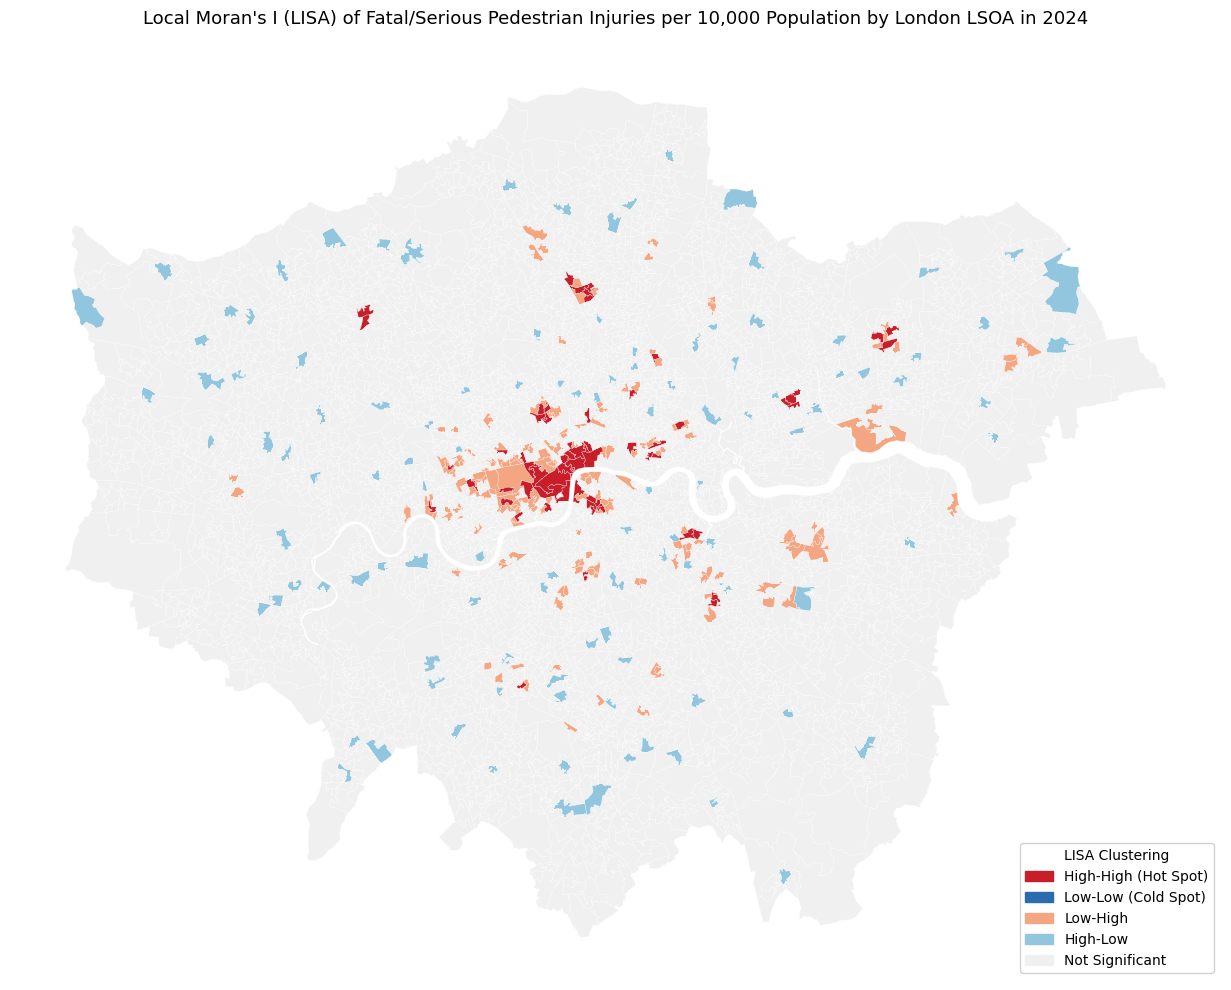

In [29]:
# Plot LISA map
color_map = {
    'High-High (Hot Spot)': '#C81E2A',
    'Low-Low (Cold Spot)': '#2B6CB0',
    'Low-High': '#F4A582',
    'High-Low': '#92C5DE',
    'Not Significant': '#f0f0f0'
}
lsoa_morans['color'] = lsoa_morans['lisa_label'].map(color_map)

fig, ax = plt.subplots(figsize=(14, 10))

lsoa_morans.plot(
    color=lsoa_morans['color'],
    edgecolor='white',
    linewidth=0.2,
    ax=ax
)

patches = [
    mpatches.Patch(color=v, label=k)
    for k, v in color_map.items()
]
ax.legend(
    handles=patches,
    loc='lower right',
    fontsize=10,
    title='LISA Clustering',
    title_fontsize=10,
    framealpha=0.9
)

ax.set_title(
    f"Local Moran's I (LISA) of Fatal/Serious Pedestrian Injuries per 10,000 Population by London LSOA in 2024",
    fontsize=13, pad=15
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [48]:
# Fill missing casualty counts with zero for LSOAs with no recorded pedestrian casualties
lsoa_morans['total_casualties'] = lsoa_morans['total_casualties'].fillna(0)
lsoa_morans['fatal_serious'] = lsoa_morans['fatal_serious'].fillna(0)

# Fatal/serious pedestrian casualty rate per 10,000 residents
# This is useful for spatial comparison but is not a perfect exposure measure.
lsoa_morans['rate_per_10000'] = (
    lsoa_morans['fatal_serious'] / lsoa_morans['population'] * 10_000
).round(2)

# Severe share: proportion of pedestrian casualties in each LSOA that were fatal/serious
# This avoids using population as the denominator, but can be unstable where casualty counts are very small.
lsoa_morans['severe_share'] = np.where(
    lsoa_morans['total_casualties'] > 0,
    lsoa_morans['fatal_serious'] / lsoa_morans['total_casualties'],
    np.nan
)

# Optional: suppress severe-share values where there are very few pedestrian casualties
# This avoids over-interpreting LSOAs with only one or two casualties.
lsoa_morans['severe_share_min3'] = np.where(
    lsoa_morans['total_casualties'] >= 3,
    lsoa_morans['severe_share'],
    np.nan
)

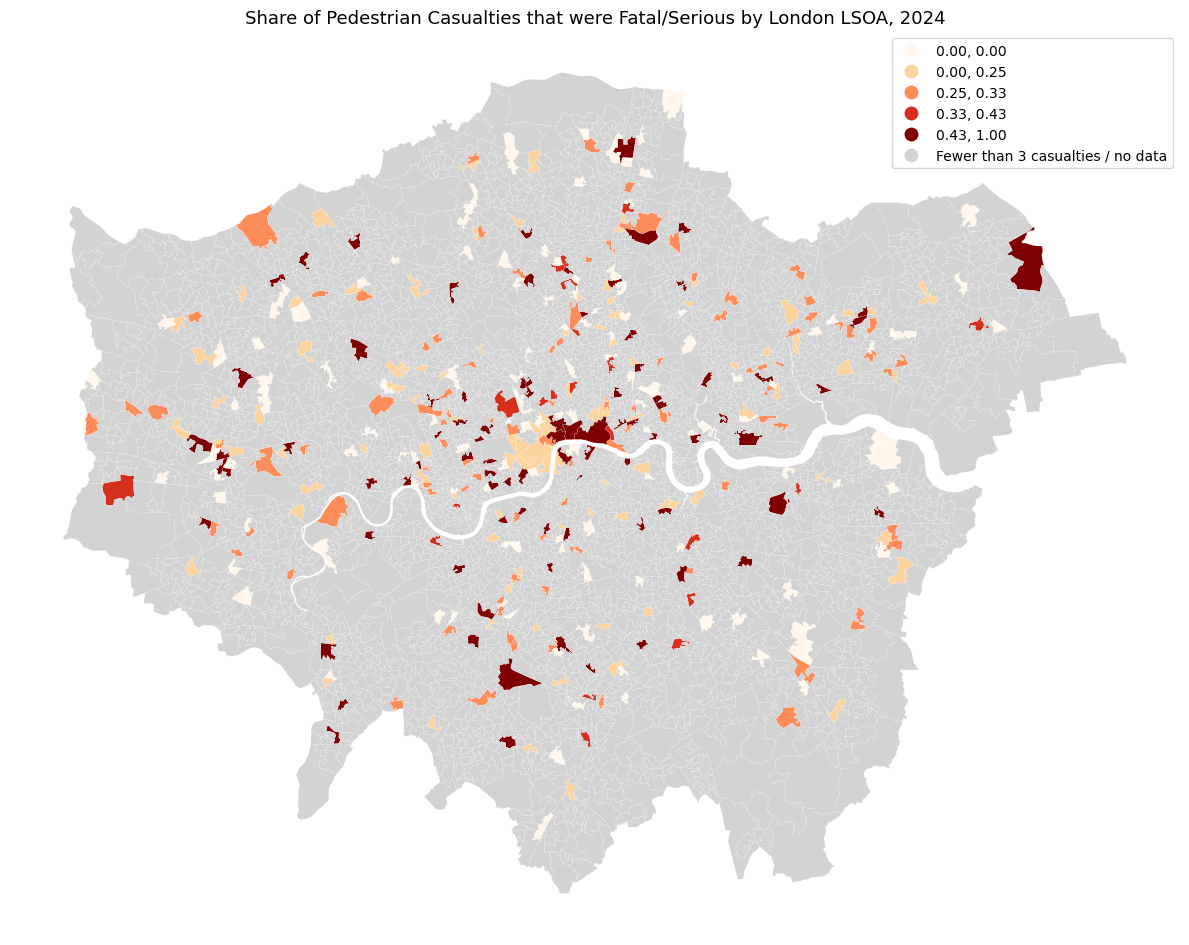

In [50]:
# Map severe share among pedestrian casualties
fig, ax = plt.subplots(figsize=(12, 10))

lsoa_morans.plot(
    column='severe_share_min3',
    cmap='OrRd',
    linewidth=0.1,
    edgecolor='white',
    legend=True,
    scheme='quantiles',
    k=5,
    ax=ax,
    missing_kwds={'color': 'lightgrey', 'label': 'Fewer than 3 casualties / no data'}
)

ax.set_title(
    'Share of Pedestrian Casualties that were Fatal/Serious by London LSOA, 2024',
    fontsize=13
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

### 5.2. Analytical Framework in Modelling

#### 5.2.1. Imputation Pipeline
This section defines pre-processing pipeline functions to impute missing values to prepare features prior modelling. Numeric variables were imputed using the median and standardised, while categorical variables were imputed with a "Missing" category and one-hot encoded. A ColumnTransformer was used to allow application of different pre-processing workflow to different columns within the machine learning pipeline.

In [30]:
# Define Imputation Pipeline
def impute_preprocess(numeric_f, categorical_f):
    
    # Numeric pipeline
    # Impute NaNs with median and standardise
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ])
    
    # Categorical pipeline
    # Impute missing with a 'Missing' category and one-hot encode
    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    
    # Apply the pipelines to its corresponding column types
    return ColumnTransformer([
        ('num', num_pipeline, numeric_f),
        ('cat', cat_pipeline, categorical_f)
    ])

#### 5.2.2. Class Imbalance

Fatal and serious casualties account for 26.9% of all observations. An unweighted tree-based classifier would tends to lean towards to predicting more slight injuries, which will give higher accuracy while failing to identify less of fatal/ serious events. Therefore, a balance class weight will be applied throughout all models. Recall will be used the primary evaluation metric alongside PR-AUC, as failing to identify a fatal/ serious event will carry greater cost than a false alarm/ or maybe F1 rather than recall to balance detecting Fatal/Serious collisions with avoiding too many false positives.

### 5.3. Train Test Split
This will be standardised to be used across all models to ensure fair comparison between models.

In [31]:
# Define input variables and target variable
X = df_clean[numeric_features + categorical_features].copy()
y = df_clean['severity_levels'].copy()

# 60% train, 20% validation, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    # Testing 20% and training + validation 80% 
    test_size= 0.20,
    # For reproducibility
    random_state= 42,
    # Ensure Fatal/ Serioous and Fatal have the same proportion amount of data
    stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    # Take 25% of the 80% for validation, which is 20% of total
    test_size= 0.25,
    random_state= 42,
    stratify=y_trainval
)

# Confirm amount of data for train validatation and testing before modelling
print(f"Train: {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Validation: {X_val.shape[0]:,} rows ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test: {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)")

Train: 2,667 rows (60%)
Validation: 889 rows (20%)
Test: 889 rows (20%)


In [32]:
# Define feature selection groups as dictionaries for later modelling

feature_groups = {
    # What can casualty factors alone predict?
    'Casualty': {
        'numeric':     casualty_numeric,
        'categorical': casualty_categorical
    },
    # What does adding temporal add on top of that?
    'Casualty + Temporal': {
        'numeric':     casualty_numeric,
        'categorical': casualty_categorical + temporal_categorical
    },
    # What does adding road add on top of that?
    'Casualty + Temporal + Road': {
        'numeric':     casualty_numeric,
        'categorical': casualty_categorical + temporal_categorical + road_categorical
    },
    # What does adding vehicle add on top of that
    'Casualty + Temporal + Road + Vehicle': {
        'numeric':     casualty_numeric,
        'categorical': casualty_categorical + temporal_categorical 
                       + road_categorical + vehicle_categorical
    }, 
    # What does greenspace add on top of everything? --> especially for answering RQ2 
    'Casualty + Temporal + Road + Vehicle + Greenspace': {
        'numeric':     casualty_numeric + greenspace_numeric,
        'categorical': casualty_categorical + temporal_categorical 
                       + road_categorical + vehicle_categorical
    }
}

### 5.4. Decision Tree Baseline Model

In [33]:
# All features will be modelled 

# Pre-process prior modelling
# Employ impute_preprocess for all features
dt_pre = impute_preprocess(numeric_features, categorical_features)

dt_pipeline = Pipeline([
    ('pre', dt_pre),
    ('clf', DecisionTreeClassifier(random_state=42))
])

# Set params
param_grid_dt = {
    'clf__max_depth': [3, 5, 10, 15, None],
    'clf__min_samples_split': [5, 10, 20],
    'clf__min_samples_leaf': [2, 4, 8],
    'clf__criterion': ['gini', 'entropy'],
    'clf__class_weight': ['balanced', {0:1, 1:2}, {0:1, 1:3}]
}

grid_dt = GridSearchCV(
    dt_pipeline, param_grid_dt,
    scoring='f1',
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    n_jobs=-1, verbose=1
)
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_

print("Best Decision Tree parameters:")
print(grid_dt.best_params_)
print(f"Best CV F1: {grid_dt.best_score_:.4f}")


# Threshold tuning on validation set
val_probs_dt = best_dt.predict_proba(X_val)[:, 1]

th_rows_dt = []
for th in np.arange(0.10, 0.91, 0.05):
    preds = (val_probs_dt >= th).astype(int)
    th_rows_dt.append({
        'threshold': round(th, 2),
        'precision': precision_score(y_val, preds, zero_division=0),
        'recall':    recall_score(y_val, preds, zero_division=0),
        'f1':        f1_score(y_val, preds, zero_division=0)
    })

th_df_dt      = pd.DataFrame(th_rows_dt).sort_values('f1', ascending=False)
best_th_dt    = th_df_dt.iloc[0]['threshold']
print(f"\nSelected threshold (val F1): {best_th_dt:.2f}")
print(th_df_dt.head())


# Refit on full training validation and evaluate on test
best_dt.fit(X_trainval, y_trainval)

test_probs_dt = best_dt.predict_proba(X_test)[:, 1]
test_pred_dt  = (test_probs_dt >= best_th_dt).astype(int)

dt_results = {
    'Accuracy':  round(accuracy_score(y_test, test_pred_dt), 4),
    'Precision': round(precision_score(y_test, test_pred_dt, zero_division=0), 4),
    'Recall':    round(recall_score(y_test, test_pred_dt, zero_division=0), 4),
    'F1':        round(f1_score(y_test, test_pred_dt, zero_division=0), 4),
    'ROC_AUC':   round(roc_auc_score(y_test, test_probs_dt), 4),
    'PR_AUC':    round(average_precision_score(y_test, test_probs_dt), 4)
}

print("\nDecision Tree Test Results:")
for k, v in dt_results.items():
    print(f"{k}:{v}")

print("\nClassification Report:")
print(classification_report(y_test, test_pred_dt, target_names=['Slight', 'Fatal/Serious']))

Fitting 5 folds for each of 270 candidates, totalling 1350 fits
Best Decision Tree parameters:
{'clf__class_weight': {0: 1, 1: 3}, 'clf__criterion': 'entropy', 'clf__max_depth': 3, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5}
Best CV F1: 0.4669

Selected threshold (val F1): 0.55
   threshold  precision    recall        f1
9       0.55   0.433692  0.506276  0.467181
8       0.50   0.311707  0.924686  0.466245
4       0.30   0.311707  0.924686  0.466245
6       0.40   0.311707  0.924686  0.466245
7       0.45   0.311707  0.924686  0.466245

Decision Tree Test Results:
Accuracy:0.6569
Precision:0.3846
Recall:0.4603
F1:0.419
ROC_AUC:0.6325
PR_AUC:0.3595

Classification Report:
               precision    recall  f1-score   support

       Slight       0.79      0.73      0.76       650
Fatal/Serious       0.38      0.46      0.42       239

     accuracy                           0.66       889
    macro avg       0.59      0.59      0.59       889
 weighted avg       0.68     

### 5.5. Random Forest Models

In [34]:
# Find the best tuning parameters from group combination of Casualty + Road + Vehicle
tune_group     = feature_groups['Casualty + Temporal + Road + Vehicle']
tune_num       = tune_group['numeric']
tune_cat       = tune_group['categorical']
tune_all       = tune_num + tune_cat

tune_pipe = Pipeline([
    ('pre',   impute_preprocess(tune_num, tune_cat)),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid_rf = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [5, 10, 15, None],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2'],
    'clf__class_weight': ['balanced', {0:1, 1:2}, {0:1, 1:3}]
}

grid_rf = GridSearchCV(
    tune_pipe, param_grid_rf,
    scoring='f1',
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    n_jobs=-1, verbose=1
)
grid_rf.fit(X_train[tune_all], y_train)

# Extract just the RF parameters (strip the pipeline prefix 'model__')
best_rf_params = {
    k.replace('clf__', ''): v
    for k, v in grid_rf.best_params_.items()
}

print("Hyperparameters for all feature groups:")
for k, v in best_rf_params.items():
    print(f"{k}: {v}")
print(f"\nBest CV F1 (tuning on Casualty + Road + Vehicle): {grid_rf.best_score_:.4f}")


# Train all four feature groups
group_results = {}   # stores test metrics for each group
group_models  = {}   # stores fitted models (needed for SHAP)

for group_name, feats in feature_groups.items():

    num_f = feats['numeric']
    cat_f = feats['categorical']
    all_f = num_f + cat_f

    # Build pipeline with the fixed hyperparameters
    pipe = Pipeline([
        ('pre', impute_preprocess(num_f, cat_f)),
        ('clf', RandomForestClassifier(
            **best_rf_params, random_state=42, n_jobs=-1
        ))
    ])

    # Calibration with isotonic
    cal = CalibratedClassifierCV(pipe, method='isotonic', cv=5)
    cal.fit(X_train[all_f], y_train)

    # Threshold tuning on validation set
    val_probs = cal.predict_proba(X_val[all_f])[:, 1]
    best_th = max(
        np.arange(0.10, 0.91, 0.05),
        key=lambda t: f1_score(
            y_val, (val_probs >= t).astype(int), zero_division=0
        )
    )

    # Refit calibrated model on full train+val, then evaluate on test
    cal.fit(X_trainval[all_f], y_trainval)
    test_probs = cal.predict_proba(X_test[all_f])[:, 1]
    test_preds = (test_probs >= best_th).astype(int)

    group_results[group_name] = {
        'Threshold': round(best_th, 2),
        'Accuracy': round(accuracy_score(y_test, test_preds), 4),
        'Precision': round(precision_score(y_test, test_preds, zero_division=0), 4),
        'Recall': round(recall_score(y_test, test_preds, zero_division=0), 4),
        'F1': round(f1_score(y_test, test_preds, zero_division=0), 4),
        'ROC_AUC': round(roc_auc_score(y_test, test_probs), 4),
        'PR_AUC': round(average_precision_score(y_test, test_probs), 4)
    }
    group_models[group_name] = {
        'calibrated': cal,
        'num': num_f, 'cat': cat_f, 'all': all_f
    }

    print(f"\n{group_name}")
    print(f"Threshold : {best_th:.2f}")
    print(f"Recall : {group_results[group_name]['Recall']}")
    print(f"PR-AUC : {group_results[group_name]['PR_AUC']}")
    print(classification_report(
        y_test, test_preds,
        target_names=['Slight', 'Fatal/Serious']
    ))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Hyperparameters for all feature groups:
class_weight: {0: 1, 1: 3}
max_depth: 5
max_features: log2
min_samples_leaf: 2
n_estimators: 300

Best CV F1 (tuning on Casualty + Road + Vehicle): 0.4671

Casualty
Threshold : 0.15
Recall : 0.9665
PR-AUC : 0.3741
               precision    recall  f1-score   support

       Slight       0.86      0.07      0.14       650
Fatal/Serious       0.28      0.97      0.43       239

     accuracy                           0.31       889
    macro avg       0.57      0.52      0.28       889
 weighted avg       0.70      0.31      0.22       889


Casualty + Temporal
Threshold : 0.20
Recall : 0.8787
PR-AUC : 0.3778
               precision    recall  f1-score   support

       Slight       0.86      0.28      0.42       650
Fatal/Serious       0.31      0.88      0.46       239

     accuracy                           0.44       889
    macro avg       0.59      0.58      0.44       889
 w

#### 5.5.1. Model Comparison

In [35]:
results_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'PR_AUC']

results_df = pd.DataFrame({
    'Decision Tree (Baseline)': dt_results,
    **{name: {k: v for k, v in res.items() if k != 'Threshold'}
       for name, res in group_results.items()}
}).T

print("\nModel Comparison")
print(results_df[results_cols].round(3))


Model Comparison
                                                   Accuracy  Precision  \
Decision Tree (Baseline)                              0.657      0.385   
Casualty                                              0.314      0.277   
Casualty + Temporal                                   0.441      0.310   
Casualty + Temporal + Road                            0.603      0.376   
Casualty + Temporal + Road + Vehicle                  0.606      0.375   
Casualty + Temporal + Road + Vehicle + Greenspace     0.667      0.414   

                                                   Recall     F1  ROC_AUC  \
Decision Tree (Baseline)                            0.460  0.419    0.632   
Casualty                                            0.966  0.431    0.633   
Casualty + Temporal                                 0.879  0.458    0.651   
Casualty + Temporal + Road                          0.720  0.494    0.698   
Casualty + Temporal + Road + Vehicle                0.699  0.488    0.682   
C

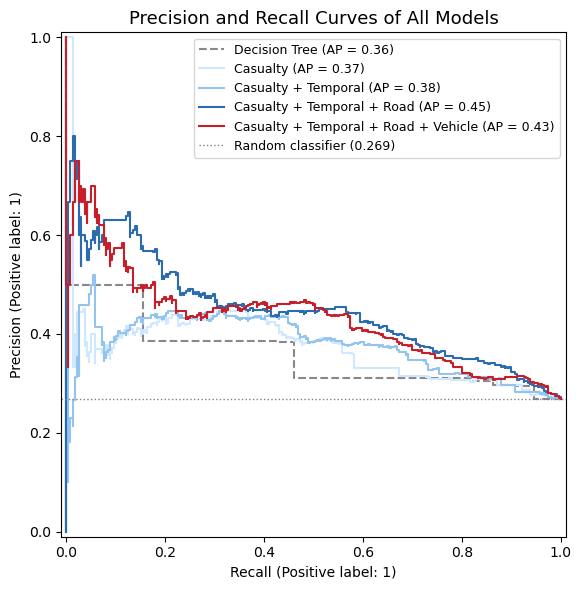

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))

# Decision Tree
PrecisionRecallDisplay.from_predictions(
    y_test, test_probs_dt,
    name="Decision Tree",
    ax=ax, color='#888888', linestyle='--'
)

# All four RF groups
colors = ['#D0E8FF', '#93C4EF', '#2B6CB0', '#C81E2A']
for (name, res), col in zip(group_results.items(), colors):
    test_probs_g = group_models[name]['calibrated'].predict_proba(
        X_test[group_models[name]['all']]
    )[:, 1]
    PrecisionRecallDisplay.from_predictions(
        y_test, test_probs_g,
        name=name,
        ax=ax, color=col
    )

ax.axhline(y=y_test.mean(), color='grey', linestyle=':', linewidth=1,
           label=f'Random classifier ({y_test.mean():.3f})')
ax.set_title('Precision and Recall Curves of All Models', fontsize=13)
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

### 5.6. SHAP Model Interpretation

In [43]:
# Model Interpretation 
#
# SHAP TreeExplainer requires direct access to the Random Forest trees.
# CalibratedClassifierCV wraps the pipeline, making the trees inaccessible.
# An uncalibrated RF with identical hyperparameters is therefore retrained
# on the full feature group (Casualty + Road + Vehicle + Greenspace)
# purely for interpretation purposes.
# Note: calibration affects probability magnitude, not feature rankings,
# so SHAP importance results remain valid for interpretation.

full_group = group_models['Casualty + Temporal + Road + Vehicle + Greenspace']
full_num   = full_group['num']
full_cat   = full_group['cat']
full_all   = full_group['all']

# Retrain uncalibrated RF with same hyperparameters on full trainval
pipe_shap = Pipeline([
    ('pre',   impute_preprocess(full_num, full_cat)),
    ('model', RandomForestClassifier(
        **best_rf_params, random_state=42, n_jobs=-1
    ))
])
pipe_shap.fit(X_trainval[full_all], y_trainval)

pre_fitted = pipe_shap.named_steps['pre']
rf_fitted  = pipe_shap.named_steps['model']

# Transform a sample of the test set
X_shap_sample = X_test[full_all].sample(n=min(500, len(X_test)), random_state=42)
X_transformed = pre_fitted.transform(X_shap_sample)

if hasattr(X_transformed, 'toarray'):
    X_transformed = X_transformed.toarray()
X_transformed = np.asarray(X_transformed, dtype=np.float64)

# Clean feature names after one-hot encoding
raw_names   = pre_fitted.get_feature_names_out()
clean_names = [n.replace('num__', '').replace('cat__', '') for n in raw_names]

# Compute SHAP values
explainer   = shap.TreeExplainer(rf_fitted)
shap_values = explainer(X_transformed)

# Keep class 1 = Fatal/Serious
shap_class1 = shap.Explanation(
    values        = shap_values.values[:, :, 1],
    base_values   = shap_values.base_values[:, 1],
    data          = shap_values.data,
    feature_names = clean_names
)

# Group one-hot dummies back to original variable names for easier interpretation
all_original = full_num + full_cat
feat_names   = list(clean_names)
shap_vals    = shap_class1.values

grouped_shap = np.zeros((shap_vals.shape[0], len(all_original)))
grouped_data = np.zeros((shap_vals.shape[0], len(all_original)))

for col_idx, orig in enumerate(all_original):
    if orig in full_num:
        if orig in feat_names:
            i = feat_names.index(orig)
            grouped_shap[:, col_idx] = shap_vals[:, i]
            grouped_data[:, col_idx] = shap_class1.data[:, i]
    else:
        indices = [
            i for i, name in enumerate(feat_names)
            if name.startswith(orig + '_') or name == orig
        ]
        if indices:
            grouped_shap[:, col_idx] = shap_vals[:, indices].sum(axis=1)
            grouped_data[:, col_idx] = np.abs(shap_vals[:, indices]).sum(axis=1)

grouped_explanation = shap.Explanation(
    values        = grouped_shap,
    base_values   = shap_class1.base_values,
    data          = grouped_data,
    feature_names = all_original
)

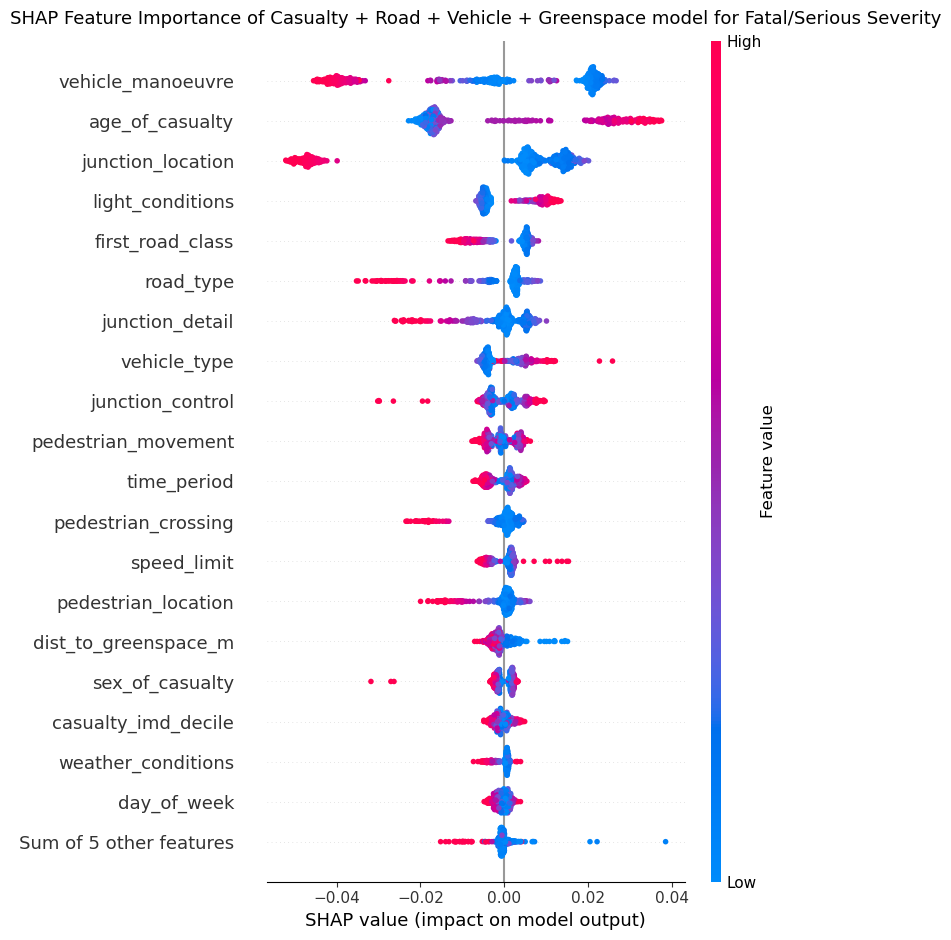

In [44]:
# SHAP Beeswarm 
shap.plots.beeswarm(grouped_explanation, max_display=20, show=False)
plt.title('SHAP Feature Importance of Casualty + Road + Vehicle + Greenspace model for Fatal/Serious Severity', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

In [45]:
# SHAP ranking table
shap_ranked = pd.Series(
    np.abs(grouped_explanation.values).mean(axis=0),
    index=all_original
).sort_values(ascending=False)

print("Features ranked by mean SHAP value:")
print(shap_ranked.round(5).to_string())

gs_rank = list(shap_ranked.index).index('dist_to_greenspace_m') + 1
print(f"\nGreenspace mean SHAP : {shap_ranked['dist_to_greenspace_m']:.5f}")
print(f"Greenspace rank : {gs_rank} of {len(shap_ranked)}")

Features ranked by mean SHAP value:
vehicle_manoeuvre                     0.02248
age_of_casualty                       0.01987
junction_location                     0.01852
light_conditions                      0.00629
first_road_class                      0.00621
road_type                             0.00541
junction_detail                       0.00461
vehicle_type                          0.00454
junction_control                      0.00378
pedestrian_movement                   0.00298
time_period                           0.00286
pedestrian_crossing                   0.00264
speed_limit                           0.00258
pedestrian_location                   0.00249
dist_to_greenspace_m                  0.00219
sex_of_casualty                       0.00196
casualty_imd_decile                   0.00148
weather_conditions                    0.00138
day_of_week                           0.00133
road_surface_conditions               0.00086
day_type                              0.0006

While distance to greenspace ranked 12th out of 21 features, an analysis of the mean absolute SHAP values reveals its impact is negligible. Top predictors such as junction location and vehicle manoeuvre exhibited SHAP values roughly ten times larger than greenspace proximity. This confirms that while greenspace may increase pedestrian exposure, the severity of collisions is overwhelmingly dictated by junction design, vehicle behavior, and casualty age.

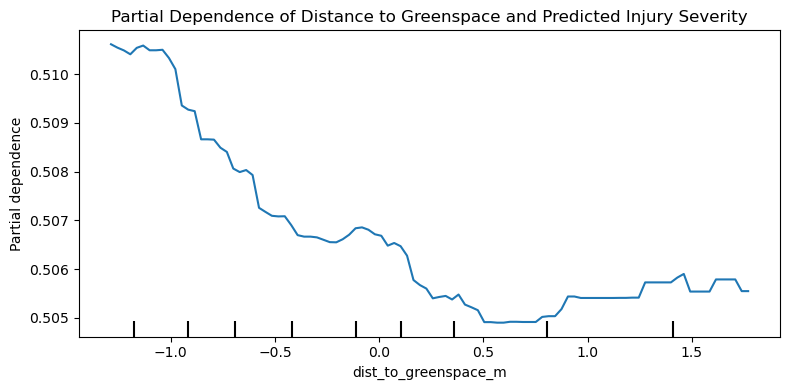

In [46]:
# Partial Dependence Plot for Greenspace 
gs_idx = list(clean_names).index('dist_to_greenspace_m')

fig, ax = plt.subplots(figsize=(8, 4))
PartialDependenceDisplay.from_estimator(
    rf_fitted,
    X_transformed,
    features=[gs_idx],
    feature_names=clean_names,
    ax=ax,
    kind='average'
)
ax.set_title(
    'Partial Dependence of Distance to Greenspace and Predicted Injury Severity',
    fontsize=12
)
ax.set_xlabel('Distance to Nearest Greenspace Access Point (standardised)')
ax.set_ylabel('Predicted Probability of Fatal/Serious Injury')
plt.tight_layout()
plt.show()

This partial dependence showed that while there is a slight increase in predicted injury severity when a pedestrian is in very close proximity to a greenspace access point. Values below zero indicate collisions closer than the average greenspace distance, while values above zero indicate collisions farther than average. The curve shows only a very small change in predicted fatal/serious injury probability across the observed range, suggesting that greenspace proximity has limited marginal influence in the model.

## 6. Discussion

[[ go back to the top ]](#Table-of-contents)

Overall, the models improved substantially over the baseline fatal/serious prevalence rate, with PR-AUC values around 0.44 compared with a random baseline of approximately 0.27. However, F1-scores remained below 0.50, indicating that models struggled to balance identifying fatal/serious casualties with avoiding false positives. This suggests that the available collision, casualty, road, vehicle, temporal, and greenspace variables do capture some relevant severity patterns, yet may struggle to fully explain pedestrian injury severity outcomes.

**RQ1**

**RQ2**

Limitations, data is police officer recorded observations dataset, class imbalance dataset...

Although Global Moran’s I was found statistically significant, it only indicates weak spatial autocorrelation in fatal/serious pedestrian injury rates. Therefore, methodologically, spatial cross-validation can be considered to test spatial dependence and whether model performance is robust in predicting across unseen areas. 

Furthermore, future research could consider pedestrian volume, as without controlling for footfall exposure, a high collision rate near greenspace may simply reflect greater pedestrian activity rather than dangerous infrastructure. Therefore, incorporating active travel exposure would substantially strengthen the model's interpretive validity. Furthermore, treating all greenspaces as equivalent by proximity alone may oversimplify their pedestrian impact. Larger and more well-connected parks may generate a greater 'halo effect' than small local greenspaces. Therefore, weighting greenspace proximity by size and accessibility in models may provide a more spatially nuanced analysis. 

## 7. Conclusion

[[ go back to the top ]](#Table-of-contents)

To conclude, this analysis examined whether proximity to urban greenspace access points adds explanatory value for predicting fatal/ serious pedestrian injury outcomes in London. The results suggest that greenspace proximity contributes limited additional predictive value once casualty, temporal, road, and vehicle factors are included. Under SHAP model interpretation, distance to greenspace ranked below key collision variables such as vehicle manoeuvre, casualty age, junction location, light conditions, and road class. The partial dependence analysis also suggested only a small marginal change in predicted fatal/ serious injury probability across greenspace distance values.

Therefore, findings did not show a strong independent relationship between greenspace proximity and pedestrian injury severity. Instead, pedestrian severity outcomes tends to be more strongly shaped by collision and road-environment characteristics. While it is intuitive that physical greenspace does not natively prevent collisions, urban policy often relies on the 'halo effect' of green infrastructure to promote active travel. Therefore, the findings suggests that road safety interventions around pedestrian movement, junction design, vehicle behaviour, and speed environments remain more directly relevant than greenspace proximity alone. However, because this study does not include pedestrian exposure or footfall data, this remains a limitation in identifying whether areas proximity to greenspace are more or less risk to fatal/ serious collision events for pedestrian activities, which could be considered in future research.

## 8. References

[[ go back to the top ]](#Table-of-contents)